In [1]:
import gc
import os
import time
import statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from memory_profiler import memory_usage
from agtools.assemblers import spades

# Profiling code

In [4]:
# GFA Line Count
def grep_count(line_prefix, file_path):
    if not os.path.exists(file_path):
        return 0
    with open(file_path, 'r') as f:
        return sum(1 for line in f if line.startswith(line_prefix))

# Get file size in MB
def get_file_size(path):
    if os.path.exists(path):
        return os.path.getsize(path) / (1024 * 1024)  # Convert to MB
    return 0.0

In [5]:
def profile_get_contig_graph(graph_file, contigs_file, contig_paths_file):
    start = time.perf_counter()
    
    mem_trace, _ = memory_usage(
        (spades.get_contig_graph, (graph_file, contigs_file, contig_paths_file)),
        retval=True,
        interval=0.01,
        timeout=None
    )
    
    end = time.perf_counter()
    
    elapsed = end - start
    peak_mem = max(mem_trace) - min(mem_trace)
    
    return elapsed, peak_mem

def profile_folder(folder_path, runs=10):
    graph_file = os.path.join(folder_path, "assembly_graph_after_simplification.gfa")
    contigs_file = os.path.join(folder_path, "contigs.fasta")
    contig_paths_file = os.path.join(folder_path, "contigs.paths")

    times = []
    peak_mems = []

    for _ in range(runs):
        elapsed, peak = profile_get_contig_graph(graph_file, contigs_file, contig_paths_file)
        times.append(elapsed)
        peak_mems.append(peak)

    # GFA line stats
    count_S = grep_count("S", graph_file)
    count_L = grep_count("L", graph_file)
    count_P = grep_count("P", graph_file)

    # File sizes in MB
    size_graph = get_file_size(graph_file)
    size_fasta = get_file_size(contigs_file)
    size_paths = get_file_size(contig_paths_file) 

    return {
        "folder": os.path.basename(folder_path),
        "time_min": min(times),
        "time_max": max(times),
        "time_mean": statistics.mean(times),
        "time_std": statistics.stdev(times),
        "peak_mem_min": min(peak_mems),
        "peak_mem_max": max(peak_mems),
        "peak_mem_mean": statistics.mean(peak_mems),
        "peak_mem_std": statistics.stdev(peak_mems),
        "gfa_S": count_S,
        "gfa_L": count_L,
        "gfa_P": count_P,
        "size_graph_MB": size_graph,
        "size_fasta_MB": size_fasta,
        "size_paths_MB": size_paths,
    }

def batch_profile(folders, runs=10):
    results = []
    
    for folder in folders:
        
        print(f"Profiling: {folder}")
        
        stats = profile_folder(folder, runs)
        results.append(stats)
        
        # Manually trigger garbage collection
        gc.collect()
        
    return pd.DataFrame(results)

# Profile SPAdes data

In [6]:
folders = [
    "data/SPAdes/ERR2752151",
    "data/SPAdes/ERR2752163",
    "data/SPAdes/ERR2752162",
    "data/SPAdes/ERR2752160",
    "data/SPAdes/ERR2752150",
    "data/SPAdes/ERR2752154",
    "data/SPAdes/ERR2752153",
    "data/SPAdes/ERR594355",
    "data/SPAdes/ERR599362",
    "data/SPAdes/ERR594375",
    "data/SPAdes/ERR594362",
    "data/SPAdes/ERR594361",
    "data/SPAdes/ERR2750828",
    "data/SPAdes/ERR599357",
    "data/SPAdes/ERR2750826",
    "data/SPAdes/ERR594360",
    "data/SPAdes/ERR599383",
    "data/SPAdes/ERR599370",
    "data/SPAdes/ERR321017",
    "data/SPAdes/ERR321018",
]

# Run profiling
df_results = batch_profile(folders, runs=10)

Profiling: data/SPAdes/Bf11
Profiling: data/SPAdes/ERR594370
Profiling: data/SPAdes/ERR594371
Profiling: data/SPAdes/ERR594372
Profiling: data/SPAdes/ERR594375


In [7]:
# Show results
df_results

,folder,time_min,time_max,time_mean,time_std,peak_mem_min,peak_mem_max,peak_mem_mean,peak_mem_std,gfa_S,gfa_L,gfa_P,size_graph_MB,size_fasta_MB,size_paths_MB
0,Bf11,4.617874,4.833418,4.732145,0.064243,223.125000,359.656250,260.393750,40.889728,156837,227316,141118,37.534231,24.518517,12.433994
1,ERR594370,40.605726,41.899567,41.251265,0.455168,2071.734375,2459.156250,2174.551562,106.694159,1539693,1144771,1047091,568.532379,448.148198,98.693966
2,ERR594371,23.728946,24.323937,24.017413,0.201662,916.453125,1018.640625,931.665625,30.870036,817317,427836,667269,295.172157,244.612451,60.958474
3,ERR594372,27.584256,28.316883,27.948002,0.265306,1085.781250,1131.531250,1099.059375,12.418761,957787,523236,769261,344.067554,283.172933,70.305538
4,ERR594375,55.274250,57.171979,56.382209,0.547331,2574.718750,2688.031250,2648.685937,31.823631,1978224,1443623,1358204,816.435465,665.080350,128.980248


In [8]:
# Save to CSV
df_results.to_csv("data/profiling_spades.csv", index=False)

# Plot

In [2]:
# Read the profiling results from CSV file
df_results = pd.read_csv("data/profiling_spades.csv")

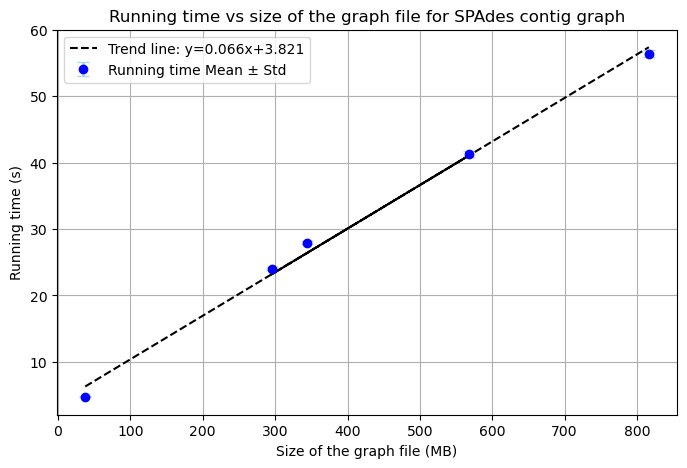

In [3]:
x = df_results["size_graph_MB"]
y = df_results["time_mean"]
yerr = df_results["time_std"]

# Fit a simple linear regression for the trend line
m, b = np.polyfit(x, y, 1)  # slope, intercept
trend_y = m * x + b

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=yerr, fmt='o', color='blue',
             ecolor='lightblue', elinewidth=2, capsize=4,
             label='Running time Mean ± Std')

# Plot trend line
plt.plot(x, trend_y, '--', color='black', label=f'Trend line: y={m:.3f}x+{b:.3f}')

plt.xlabel("Size of the graph file (MB)")
plt.ylabel("Running time (s)")
plt.title("Running time vs size of the graph file for SPAdes contig graph")
plt.legend()
plt.grid(True)

# Save to file
plt.savefig("spades_time.png", dpi=300, bbox_inches='tight')
plt.show()

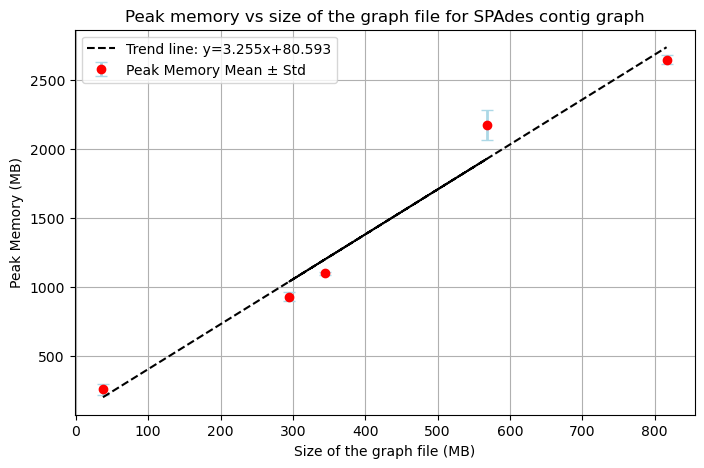

In [4]:
# Plot Peak Memory Mean with error bars
x = df_results["size_graph_MB"]
y = df_results["peak_mem_mean"]
yerr = df_results["peak_mem_std"]

# Fit a simple linear regression for the trend line
m, b = np.polyfit(x, y, 1)  # slope, intercept
trend_y = m * x + b

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=yerr, fmt='o', color='red',
             ecolor='lightblue', elinewidth=2, capsize=4,
             label='Peak Memory Mean ± Std')

# Plot trend line
plt.plot(x, trend_y, '--', color='black', label=f'Trend line: y={m:.3f}x+{b:.3f}')

plt.xlabel("Size of the graph file (MB)")
plt.ylabel("Peak Memory (MB)")
plt.title("Peak memory vs size of the graph file for SPAdes contig graph")
plt.legend()
plt.grid(True)

# Save to file
plt.savefig("spades_mem.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# %%time
# %%memit

# cg = spades.get_contig_graph(
#     f"{folder_path}/assembly_graph_with_scaffolds.gfa", 
#     f"{folder_path}/contigs.fasta", 
#     f"{folder_path}/contigs.paths"
# )